In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('wine_data.csv')


In [5]:
df.sample(5)

,1,14.23,1.71,2.43,15.6,127,2.8,3.06,.28,2.29,5.64,1.04,3.92,1065
64,2,12.37,1.21,2.56,18.1,98,2.42,2.65,0.37,2.08,4.60,1.19,2.30,678
128,2,12.04,4.30,2.38,22.0,80,2.10,1.75,0.42,1.35,2.60,0.79,2.57,580
83,2,11.84,0.89,2.58,18.0,94,2.20,2.21,0.22,2.35,3.05,0.79,3.08,520
174,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
24,1,13.05,2.05,3.22,25.0,124,2.63,2.68,0.47,1.92,3.58,1.13,3.20,830


In [6]:
df=pd.read_csv('wine_data.csv',usecols=[0,1,2])
df.columns=['Class Label','Alcohol','Malic Acid']

In [7]:
df.sample(10)

,Class Label,Alcohol,Malic Acid
54,1,13.56,1.73
130,3,12.88,2.99
36,1,13.05,1.65
121,2,12.42,4.43
15,1,14.30,1.92
133,3,12.51,1.24
83,2,11.84,0.89
34,1,13.48,1.81
80,2,12.72,1.81
61,2,13.67,1.25


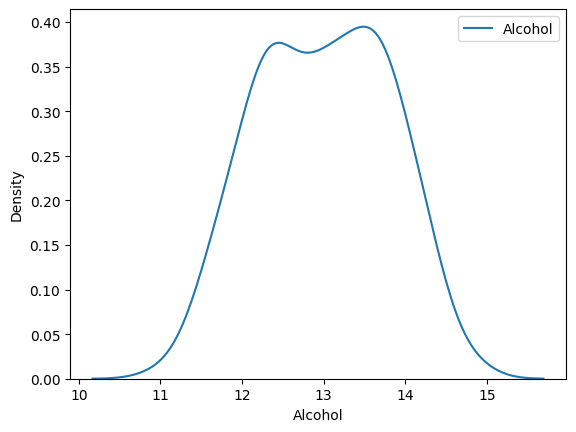

In [8]:
# sns.distplot(df['Alcohol'],label='Alcohol',hist=False)
# plt.legend()

sns.kdeplot(df['Alcohol'],label='Alcohol')
plt.legend()

# both do same but distplot is deprecated

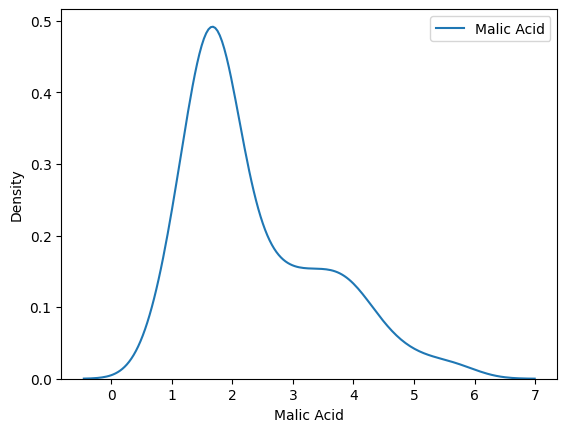

In [9]:
sns.kdeplot(df['Malic Acid'],label='Malic Acid')
plt.legend()

<Axes: xlabel='Alcohol', ylabel='Malic Acid'>

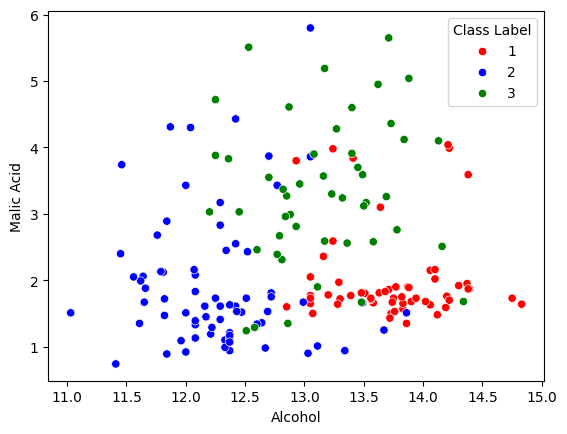

In [10]:
colour_dict={1:'red',2:'blue',3:'green'}
sns.scatterplot(x=df['Alcohol'],y=df['Malic Acid'],hue=df['Class Label'],palette = colour_dict)

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train,X_test,y_train,y_test = train_test_split(df.drop('Class Label' , axis=1),df['Class Label'],test_size=0.2,random_state=0)

In [13]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
scaler.fit(X_train) # parameters j joyta hoy ae learn kare like min and max gote in this case
X_train_scaled = scaler.transform(X_train) # formula apply kare
X_test_scaled = scaler.transform(X_test) # formula apply kare

In [14]:
X_train_scaled = pd.DataFrame(X_train_scaled,columns = X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled,columns = X_test.columns)

In [15]:
np.round(X_train_scaled.describe(),1)

,Alcohol,Malic Acid
count,141.0,141.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.1
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


In [16]:
np.round(X_train.describe(),1)

,Alcohol,Malic Acid
count,141.0,141.0
mean,13.0,2.3
std,0.8,1.1
min,11.0,0.9
25%,12.3,1.6
50%,13.0,1.9
75%,13.6,3.1
max,14.8,5.8


<Axes: xlabel='Alcohol', ylabel='Malic Acid'>

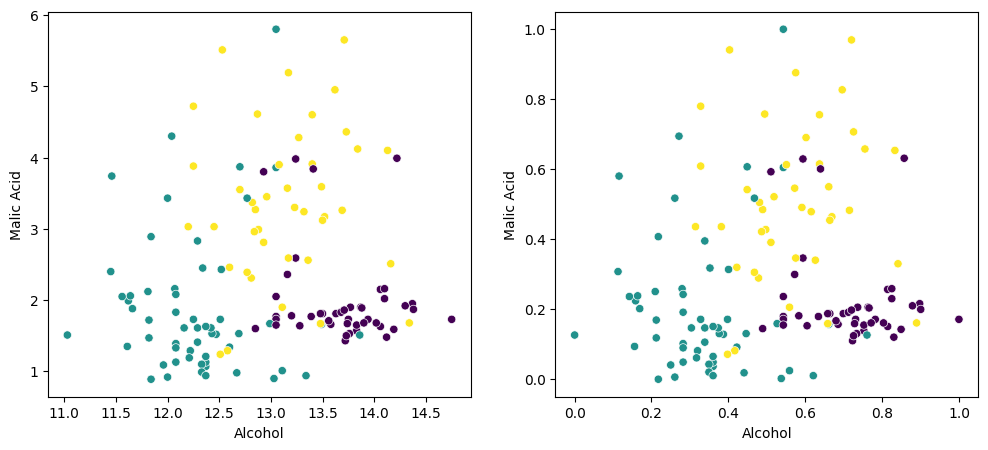

In [17]:
fig,(ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))
sns.scatterplot(x=X_train['Alcohol'],y=X_train['Malic Acid'],c=y_train,ax=ax1)
sns.scatterplot(x=X_train_scaled['Alcohol'],y=X_train_scaled['Malic Acid'],c=y_train,ax=ax2)


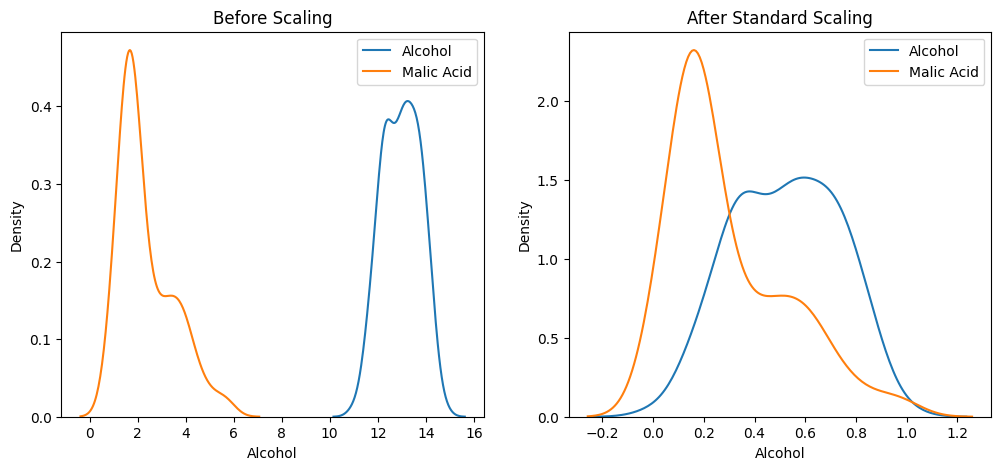

In [18]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1, label='Alcohol')
sns.kdeplot(X_train['Malic Acid'], ax=ax1, label='Malic Acid')
ax1.legend()

ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2, label='Alcohol')
sns.kdeplot(X_train_scaled['Malic Acid'], ax=ax2, label='Malic Acid')
ax2.legend()

In [19]:
from sklearn.preprocessing import MaxAbsScaler

In [20]:
S = MaxAbsScaler()
S.fit(X_train)
X_train_MaxS = S.transform(X_train)
X_test_MaxS = S.transform(X_test)

In [21]:
X_train_MaxS = pd.DataFrame(X_train_MaxS,columns=X_train.columns)
X_test_MaxS = pd.DataFrame(X_test_MaxS,columns=X_test.columns)

In [22]:
np.round(X_train_MaxS.describe(),1)

,Alcohol,Malic Acid
count,141.0,141.0
mean,0.9,0.4
std,0.1,0.2
min,0.7,0.2
25%,0.8,0.3
50%,0.9,0.3
75%,0.9,0.5
max,1.0,1.0


In [23]:
np.round(X_train.describe(),1)

,Alcohol,Malic Acid
count,141.0,141.0
mean,13.0,2.3
std,0.8,1.1
min,11.0,0.9
25%,12.3,1.6
50%,13.0,1.9
75%,13.6,3.1
max,14.8,5.8


In [24]:
from sklearn.linear_model import LogisticRegression

In [25]:
lr=LogisticRegression()
lr_scaled = LogisticRegression()

lr.fit(X_train,y_train)
lr_scaled.fit(X_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [26]:
y_pred = lr.predict(X_test)
y_pred_scaled = lr_scaled.predict(X_test_scaled)

In [27]:
from sklearn.metrics import accuracy_score

In [28]:
print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.7777777777777778
Scaled 0.7222222222222222


In [30]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

scores_unscaled = cross_val_score(LogisticRegression(), X_train, y_train, cv=5)
scores_scaled = cross_val_score(LogisticRegression(), X_train_scaled, y_train, cv=5)

print("Unscaled avg:", scores_unscaled.mean())
print("Scaled avg:", scores_scaled.mean())

Unscaled avg: 0.7733990147783251
Scaled avg: 0.7948275862068965


In [32]:
lr.fit(X_train,y_train)
lr_scaled.fit(X_train_MaxS,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [33]:
y_predS = lr.predict(X_test)
y_predS_scaled = lr_scaled.predict(X_test_MaxS)

In [34]:
print("Actual",accuracy_score(y_test,y_predS))
print("Scaled",accuracy_score(y_test,y_predS_scaled))

Actual 0.7777777777777778
Scaled 0.5555555555555556


In [36]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

scores_unscaled = cross_val_score(LogisticRegression(), X_train, y_train, cv=5)
scores_maxabs = cross_val_score(LogisticRegression(), X_train_MaxS, y_train, cv=5)

print("Unscaled avg:", scores_unscaled.mean())
print("MaxAbs avg:", scores_maxabs.mean())

Unscaled avg: 0.7733990147783251
MaxAbs avg: 0.6029556650246305
